# 📓 **Notebook 1 — Phases 1 & 2**

**Project:** [Medical Transcription Classfier and Semantic Search Engine Project](https://github.com/bahadirkoko/medical-transcription-classifier)

## **Medical Transcription Analysis — Phases 1 & 2**

This notebook covers exploratory analysis and statistical feature analysis of the
Medical Transcriptions dataset, preparing the groundwork for classification (Phase 3)
and semantic search (Phase 4).

## **Phase 1 — EDA & NLP Foundations**
Clean the data and understand the linguistic "fingerprint" of each medical specialty.
- **1.1 Cleaning & Features** — remove nulls/duplicates/short notes; compute length,
  word, and sentence counts; visualize class distribution and note lengths.
- **1.2 NLP Analysis** — preprocess text (lowercase, remove punctuation, drop stopwords);
  find top words, bigrams, and trigrams per specialty.

## **Phase 2 — Statistical Significance & Linguistic Importance**
Statistically measure which words and phrases are tied to each specialty.
- **2.1 Chi-Square** — tests which words are statistically "locked" to a specialty.
- **2.2 N-Grams + PMI** — finds meaningful medical phrases vs. random word pairings.
- **2.3 TF-IDF** — scores words by uniqueness, filtering out common "medical noise."


---

### 🗂️ **Project notebooks**
1. **Notebook 1** — Phases 1 & 2: Collection & Cleaning **(you are here)**
2. Notebook 2 — Phase 3: Exploratory Analysis
3. Notebook 3 — Phases 4 & 5: Feature Engineering & Modeling

In [129]:
#data libraries
import pandas as pd
import numpy as np

#visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#text/NLP libraries
import re #punctuation removal
import nltk #cleaning, tokenization, stopword removal, n-grams
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.util import ngrams
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
from collections import Counter #n-gram frequency counting

#ML work phase 1.2, vectorization and phase 2
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.feature_selection import chi2

#NLTK data downloads
nltk.download('punkt') #downloads the Punkt tokenizer models, which are used for sentence splitting and tokenization.
nltk.download('punkt_tab') #downloads the Punkt tokenizer models for tokenizing text into sentences and words, specifically for tab-separated text.
nltk.download('stopwords') #downloads the stopwords corpus, which contains a list of common stopwords in various languages that can be used for text preprocessing and filtering.


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/bahadirkocabas/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/bahadirkocabas/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/bahadirkocabas/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Phase 1.1 EDA

Before any cleaning, we load the raw dataset and inspect its structure —
dimensions, column quality (nulls and duplicates), and transcription length
distribution. This informs every cleaning decision that follows: we only
drop what we can justify from what we observe here.


In [130]:
df = pd.read_csv('../data/raw/medicaltranscriptionsamples.csv') #loading data from a relative path

print("Rows:", df.shape[0], "Columns:", df.shape[1]) #to get the number of rows and columns in the DataFrame
display(df.head())

df = df.drop(columns=['Unnamed: 0']) #dropping the unnamed column 

null_and_duplicated = pd.DataFrame({
    'null_%': (df.isnull().sum() / len(df) * 100).round(2), #getting the percentage of null values in each column, rounded to 2 decimal places, no need for lambda because .isnull works on the entire DataFrame and returns a Series with the count of null values for each column.
    'duplicated_%': (df.apply(lambda c: c.duplicated().sum()) / len(df) * 100).round(2) # duplicated() is series method, so we need to apply it to each column using apply() and then sum the boolean values to get the count of duplicated values for each column. Then we divide by the total number of rows and multiply by 100 to get the percentage of duplicated values in each column, rounded to 2 decimal places.
})
display(null_and_duplicated)

print(f"Missing values in 'medical_specialty': {df['medical_specialty'].isna().sum()}") #checking for missing values 
print(f"Missing values in 'transcription': {df['transcription'].isna().sum()}")

thresholds = [20, 50, 100, 200, 500] #transcription char length checking

threshold_summary = pd.DataFrame({
    'threshold': thresholds,
    'count': [( df['transcription'].str.len() < t).sum() for t in thresholds]}) #loop each threshhold and count len of transcriptions

display(threshold_summary)



Rows: 4999 Columns: 6


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


,null_%,duplicated_%
description,0.00,53.03
medical_specialty,0.00,99.20
sample_name,0.00,52.45
transcription,0.66,52.83
keywords,21.36,22.98


Missing values in 'medical_specialty': 0
Missing values in 'transcription': 33


,threshold,count
0,20,14
1,50,23
2,100,45
3,200,64
4,500,132


**Key Findings:**

- **medical_specialty:** 0 nulls, ~99% duplicated — expected for a categorical
  column with only ~30 distinct values. Not a concern.

- **transcription:** 33 nulls (to be dropped) and ~52% duplicated values.
  The high duplication rate suggests the same clinical note is cross-listed
  under multiple specialties — a structural property of this dataset worth
  investigating before modeling, as it affects train/test integrity.

- **Short notes:** a meaningful number of transcriptions have very few
  characters. Notes under a minimum threshold likely lack enough content
  to carry specialty signal and will be considered for removal after
  further inspection.

In [131]:
# specialty counts to inform our dropping decisions
specialty_summary = (
    df.groupby('medical_specialty')['transcription'] #groupby specialties to see how much notes we have
    .count()
    .reset_index() #reset index
    .rename(columns={'transcription': 'note_count'})
    .sort_values('note_count', ascending=False)
    .assign(percentage=lambda x: (x['note_count'] / len(df) * 100).round(2)) #adding another column and applying percentage formula to each specialty, used assign not to break mid way df creation
    .reset_index(drop=True) #reset index again to finalize
)
display(specialty_summary)

print(f"total specialties: {specialty_summary['medical_specialty'].nunique()}") #count number of unique labels
print(f"specialties with < 20 notes: {(specialty_summary['note_count'] < 20).sum()}")
print(f"specialties with < 10 notes: {(specialty_summary['note_count'] < 10).sum()}")




,medical_specialty,note_count,percentage
0,Surgery,1088,21.76
1,Consult - History and Phy.,516,10.32
2,Cardiovascular / Pulmonary,371,7.42
3,Orthopedic,355,7.10
4,Radiology,273,5.46
5,General Medicine,259,5.18
6,Gastroenterology,224,4.48
7,Neurology,223,4.46
8,SOAP / Chart / Progress Notes,166,3.32
9,Urology,156,3.12


total specialties: 40
specialties with < 20 notes: 11
specialties with < 10 notes: 5


**Key findings:**

The dataset contains **40 labeled specialties**, but not all are genuine
clinical fields. Some labels describe **document formats** (SOAP Notes,
Letters, Discharge Summaries, etc.) rather than medical specialties —
these likely represent the same transcriptions re-labeled for administrative
purposes.

**Two issues to address before modeling:**

1. **Document-format labels** — non-specialty categories that overlap with
   real specialties on the same transcription text. If confirmed redundant,
   dropping them removes no unique clinical content and makes the
   classification task coherent (we classify *medical fields*, not
   *note formats*).

2. **Rare specialties** — X specialties have fewer than 10 notes and
   Y have fewer than 20. With so few examples, a model cannot learn
   reliable patterns, and stratified train/test splitting becomes
   unstable. Dropping these improves classifier reliability on the
   remaining classes.

**Next step:** verify that non-specialty transcriptions also exist under
real specialty labels before dropping — confirming no unique content
is lost.

In [132]:
not_specialties = [ #creating a list of not specilities, that is in the data set and labeled as speciality
    'SOAP / Chart / Progress Notes', 'Office Notes', 'Letters',
    'Discharge Summary', 'Emergency Room Reports',
    'Consult - History and Phy.', 'IME-QME-Work Comp etc.','Surgery'
]
# transcriptions that appear under non-specialty labels
non_spec_transcriptions = set( #creating the set because will use & and - difference + do not want to count duplicated transcription for twice.
    df[df['medical_specialty'].str.strip().isin(not_specialties)]['transcription'] #filtering the rows that are not in medical specialities and testing their uniquness
)

# transcriptions that appear under REAL specialty labels
real_spec_transcriptions = set(
    df[~df['medical_specialty'].str.strip().isin(not_specialties)]['transcription'] #transcription filtering for real specialty labels
)

# how many non-specialty transcriptions also exist under a real specialty?
also_in_real = non_spec_transcriptions & real_spec_transcriptions   # set intersection
only_in_non_spec = non_spec_transcriptions - real_spec_transcriptions  # set difference

print(f"total unique transcriptions in non-specialty rows: {len(non_spec_transcriptions)}")
print(f"of those, also labeled under a real specialty:     {len(also_in_real)}")
print(f"of those, ONLY in non-specialty (would be lost):   {len(only_in_non_spec)}")
overlap_rate = (len(also_in_real) / len(non_spec_transcriptions) * 100) if len(non_spec_transcriptions) > 0 else 0
print(f"overlap rate: {overlap_rate:.1f}%")

# get all transcriptions labeled as Surgery (strip whitespace from labels)
surgery_transcriptions = set(
    df[df['medical_specialty'].str.strip() == 'Surgery']['transcription'].str.strip()
)

# get all transcriptions labeled as OTHER real specialties
other_transcriptions = set(
    df[df['medical_specialty'].str.strip() != 'Surgery']['transcription'].str.strip()
)

# overlap
also_in_other = surgery_transcriptions & other_transcriptions
only_surgery = surgery_transcriptions - other_transcriptions

print(f"total unique Surgery transcriptions: {len(surgery_transcriptions)}")
print(f"also appear under another specialty: {len(also_in_other)}")
print(f"unique to Surgery only:              {len(only_surgery)}")
print(f"overlap rate: {len(also_in_other)/len(surgery_transcriptions)*100:.1f}%")

total unique transcriptions in non-specialty rows: 1937
of those, also labeled under a real specialty:     1854
of those, ONLY in non-specialty (would be lost):   83
overlap rate: 95.7%
total unique Surgery transcriptions: 1089
also appear under another specialty: 1040
unique to Surgery only:              49
overlap rate: 95.5%


**Key Findings:** 
- **96% overlap confirmed:** transcriptions labeled under non-specialty
  categories also appear under real specialty labels. Dropping the
  non-specialty rows removes only the redundant label — no unique
  clinical content is lost.

- **Note on the 4% remainder:** since we used sets (which count each
  unique transcription once), the non-overlapping transcriptions are
  genuinely unique to non-specialty labels with no real-specialty
  counterpart. These carry no usable specialty label for classification
  and would be dropped regardless.

- **Surgery Speciality overlaps** we also found out that surgery overlaps with real specialities
so we have same duplicate transcription, labeled as surgery but actually they have true label that represent a real specialty.


## Phase 1.1 Data Cleaning

In [133]:
print(df.shape[0],'Rows')
df = df.dropna(subset=['medical_specialty','transcription']) #to drop rows with missing values in the 'medical_specialty' column and transcription column
print(df.shape[0],'Rows')

df['medical_specialty'] = df['medical_specialty'].str.strip() #to remove leading and trailing whitespace from the 'medical_specialty' column
df['transcription'] = df['transcription'].str.strip() #to remove leading and trailing whitespace from the 'transcription' column

df = df.drop_duplicates(subset=['transcription', 'medical_specialty']) #to drop duplicate rows based on the 'transcription' column, if they had exact same notes
print(df.shape[0],'Rows')

df = df[df['transcription'].str.len() >= 100] #to filter the DataFrame to only include rows where the length of the 'transcription' column is at least 100 characters
print(df.shape[0],'Rows') #to check the shape of the DataFrame after filtering out short transcriptions

df = df[~df['medical_specialty'].isin(not_specialties)].reset_index(drop=True)  #filter out not specialities
print(df.shape[0],'Rows')

min_notes = 10 # setup threshold
counts = df['medical_specialty'].value_counts() #count noter per specialty
rare = counts[counts < min_notes].index.tolist() #applies threshold in boolean filter, filter on series count , index grabs specialty names from filtered series, convert from pandas index object to plain python list

print("rare specialties being dropped:", rare)

df = df[~df['medical_specialty'].isin(rare)].reset_index(drop=True) #drop rare specialties, reset the index column after dropping, isin retursn true first and we use ~
print("after dropping rare specialties:", len(df), "rows |", df['medical_specialty'].nunique(), "specialties") 
print(df.shape[0],'Rows')

specialty_summary = (
    df.groupby('medical_specialty')['transcription'] #groupby specialties to see how much notes we have
    .count()
    .reset_index() #reset index
    .rename(columns={'transcription': 'note_count'})
    .sort_values('note_count', ascending=False)
    .assign(percentage=lambda x: (x['note_count'] / len(df) * 100).round(2)) #adding another column and applying percentage formula to each specialty, used assign not to break mid way df creation
    .reset_index(drop=True) #reset index again to finalize
)
display(specialty_summary)


4999 Rows
4966 Rows
4964 Rows
4920 Rows
2894 Rows
rare specialties being dropped: ['Speech - Language', 'Lab Medicine - Pathology', 'Allergy / Immunology', 'Autopsy', 'Hospice - Palliative Care']
after dropping rare specialties: 2857 rows | 27 specialties
2857 Rows


,medical_specialty,note_count,percentage
0,Cardiovascular / Pulmonary,368,12.88
1,Orthopedic,346,12.11
2,Radiology,271,9.49
3,General Medicine,257,9.00
4,Neurology,223,7.81
5,Gastroenterology,220,7.70
6,Obstetrics / Gynecology,155,5.43
7,Urology,154,5.39
8,ENT - Otolaryngology,96,3.36
9,Neurosurgery,94,3.29


**Key Outcomes:**
- Null values in transcription, and specialty column dropped.
- Leading and trailing whitespaces are removed, duplicates values dropped in both transcription and medical specialty.
- Notes that have less than 100 char are dropped.
- Specialities that has less than 10 notes are dropped.
- Non-speciality values are dropped.
- After dropping non-specialties, rare classes (<10 notes), and Surgery
(96% overlap with other specialties — largely cross-listed procedural
notes):
- 27 genuine clinical specialties | ~2,857 notes
- Imbalance ratio: 36:1 (Cardiovascular 368 notes vs
  Rheumatology/Diets 10 notes each)

## Phase 1.1 Feature Extraction

In [150]:
df['char_length'] = df['transcription'].str.len() #to create a new column 'char_length' that contains the length of the text in the 'transcription' column
df['word_count'] = df['transcription'].str.split().apply(len) #to create a new column 'word_count' that contains the number, splitting by whitespace
df['sentence_count'] = df['transcription'].apply(lambda note: len(sent_tokenize(note))) #NLTK handles edge cases and abbreviations, lambda function run with apply, calculate sentence c
df[['char_length', 'word_count', 'sentence_count']].describe()




,char_length,word_count,sentence_count
count,2857.000000,2857.000000,2857.000000
mean,2965.205460,450.903745,28.536927
std,1942.007372,307.924316,19.661476
min,100.000000,9.000000,1.000000
25%,1528.000000,230.000000,14.000000
50%,2579.000000,384.000000,24.000000
75%,3928.000000,604.000000,39.000000
max,18425.000000,3029.000000,159.000000


## 1.1  Visuals

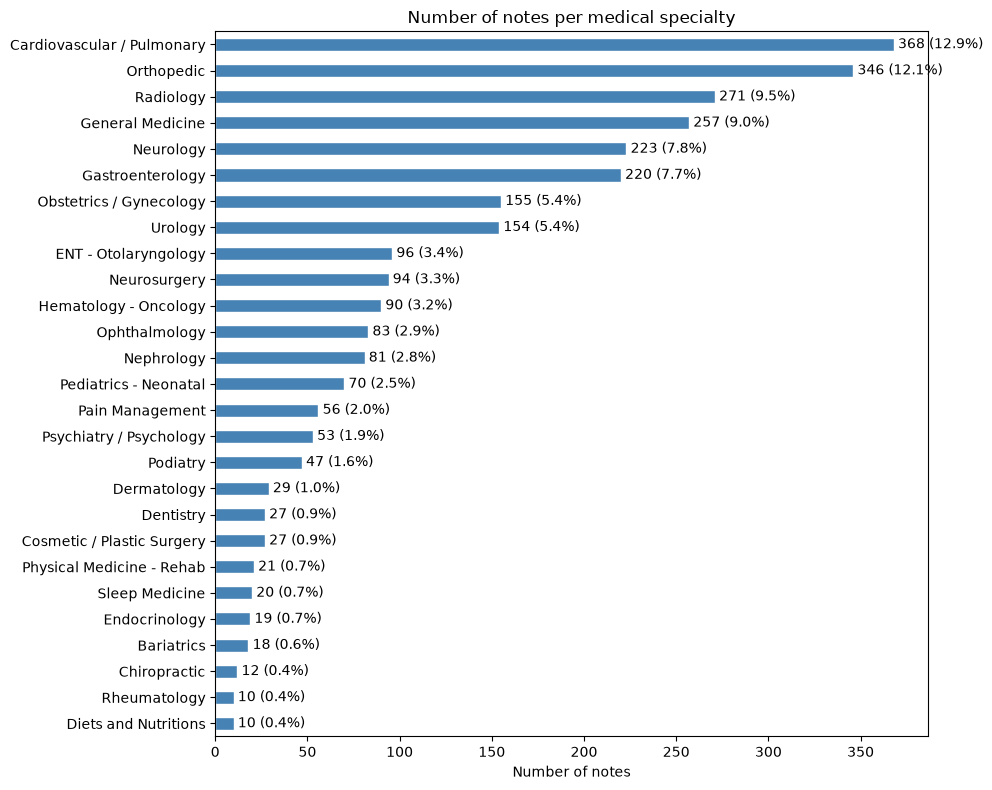

In [160]:
fig, ax = plt.subplots(figsize=(10, 8))
specialty_counts = df['medical_specialty'].value_counts().sort_values()
bars = specialty_counts.plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)

# add count labels to the end of each bar
total = len(df)
labels = [f"{v} ({v/total*100:.1f}%)" for v in specialty_counts.values]
ax.bar_label(ax.containers[0], labels=labels, padding=3)

plt.title('Number of notes per medical specialty')
plt.xlabel('Number of notes')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/specialty_counts.png', dpi=150, bbox_inches='tight')
plt.show()

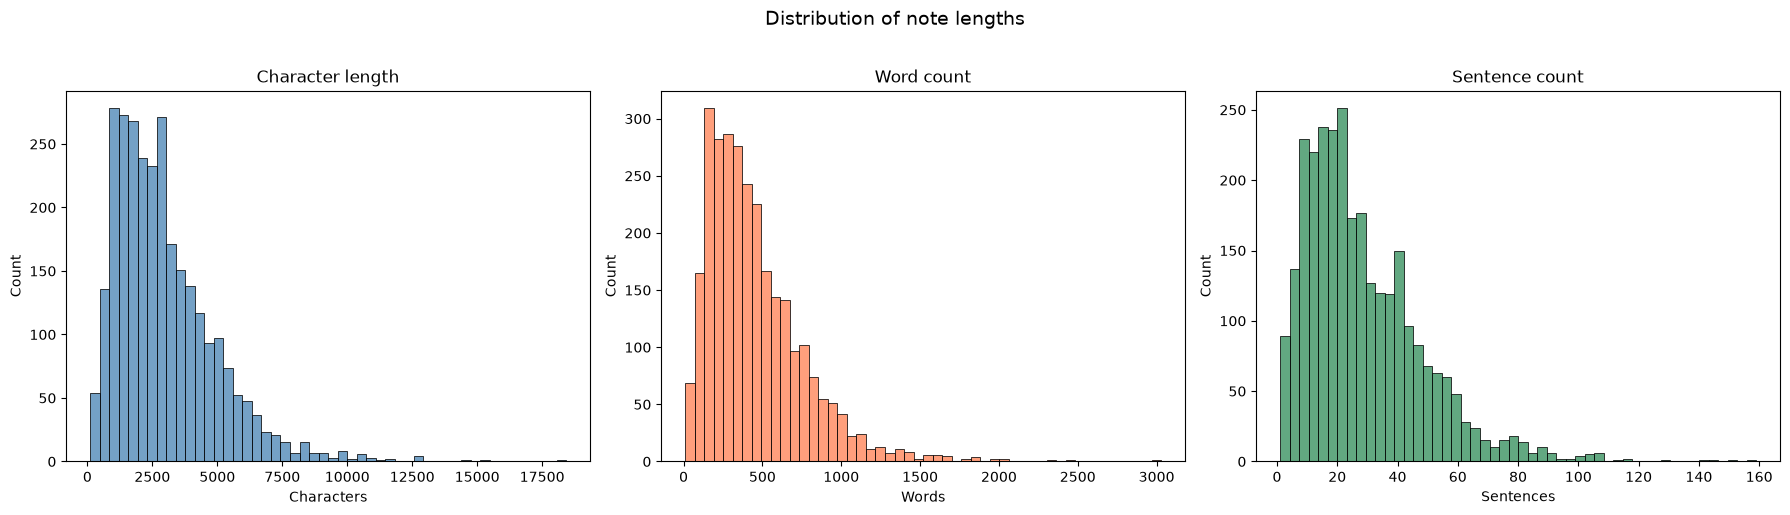

In [155]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['char_length'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Character length')
axes[0].set_xlabel('Characters')

sns.histplot(df['word_count'], bins=50, ax=axes[1], color='coral')
axes[1].set_title('Word count')
axes[1].set_xlabel('Words')

sns.histplot(df['sentence_count'], bins=50, ax=axes[2], color='seagreen')
axes[2].set_title('Sentence count')
axes[2].set_xlabel('Sentences')

fig.suptitle('Distribution of note lengths', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/length_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

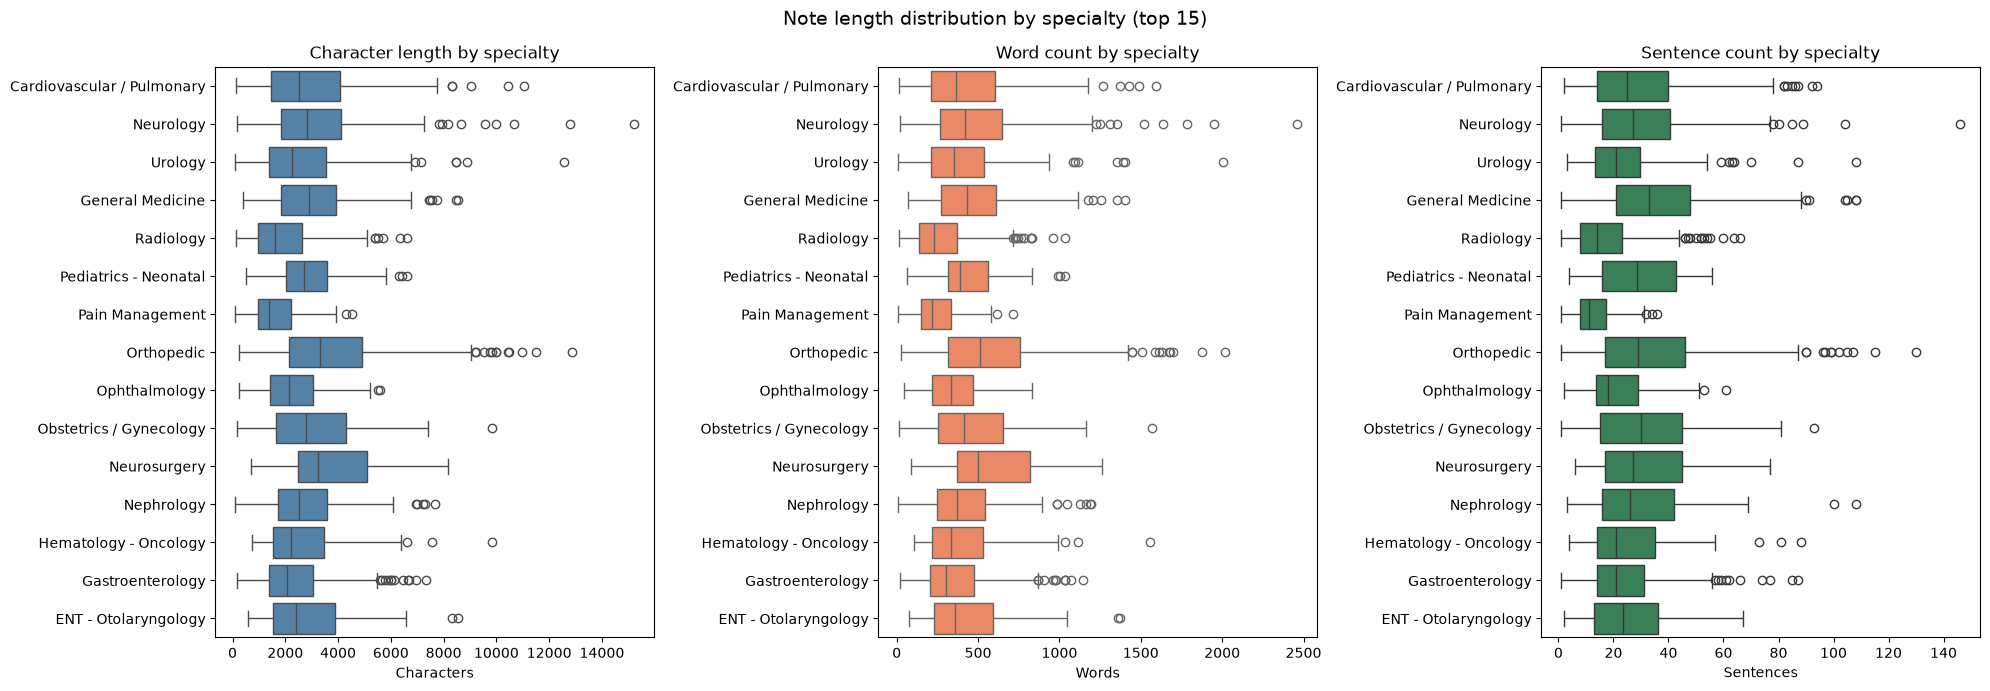

In [156]:
top_specs = df['medical_specialty'].value_counts().head(15).index
subset = df[df['medical_specialty'].isin(top_specs)]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

sns.boxplot(data=subset, y='medical_specialty', x='char_length', ax=axes[0], color='steelblue')
axes[0].set_title('Character length by specialty')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('')

sns.boxplot(data=subset, y='medical_specialty', x='word_count', ax=axes[1], color='coral')
axes[1].set_title('Word count by specialty')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('')

sns.boxplot(data=subset, y='medical_specialty', x='sentence_count', ax=axes[2], color='seagreen')
axes[2].set_title('Sentence count by specialty')
axes[2].set_xlabel('Sentences')
axes[2].set_ylabel('')

fig.suptitle('Note length distribution by specialty (top 15)', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/length_by_specialty.png', dpi=150, bbox_inches='tight')
plt.show()

1.2 NLP analysis

In [138]:
#cleaning the text data for vectorization and ML work
stop = set(stopwords.words('english'))

def clean(text):
    text = text.lower()                          # 1. lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)        # 2. remove punctuation/digits
    words = text.split()                         # 3. tokenize
    words = [w for w in words if w not in stop]  # 4. drop stopwords, using a list comprehension to filter out stopwords
    return ' '.join(words)                        # 5. rejoin

df['clean_text'] = df['transcription'].apply(clean)

df.head(1)

,description,medical_specialty,sample_name,transcription,keywords,char_length,word_count,sentence_count,clean_text
0,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh...",2431,350,25,past medical history difficulty climbing stair...


In [139]:
all_words = ' '.join(df['clean_text']).split() #create a list of all words in the 'clean_text' column by joininn and splitting the text returning a list of words to counter work
top20 = Counter(all_words).most_common(20)
print("Top 20 most common words:", top20)

Top 20 most common words: [('patient', 12952), ('right', 6682), ('left', 6584), ('history', 5079), ('normal', 4478), ('procedure', 4042), ('placed', 3823), ('well', 3526), ('pain', 3308), ('c', 2772), ('x', 2422), ('mg', 2410), ('also', 2375), ('time', 2364), ('noted', 2332), ('using', 2258), ('performed', 2248), ('without', 2106), ('blood', 2099), ('skin', 2038)]


In [140]:
print("total rows:", len(df))
print("unique transcriptions:", df['transcription'].nunique())
dup = df['transcription'].duplicated().sum()
print("duplicate transcription rows:", dup)

total rows: 2857
unique transcriptions: 2230
duplicate transcription rows: 627


In [141]:
for specialty in df['medical_specialty'].value_counts().head(5).index:
    notes = df[df['medical_specialty'] == specialty]['clean_text']
    words = ' '.join(notes).split()
    top = Counter(words).most_common(20)
    print(f"\n=== {specialty} ===")
    print(top) 


=== Cardiovascular / Pulmonary ===
[('patient', 1662), ('left', 1549), ('right', 1300), ('artery', 1085), ('coronary', 681), ('history', 654), ('normal', 648), ('procedure', 648), ('chest', 546), ('mg', 454), ('catheter', 450), ('heart', 436), ('pulmonary', 427), ('placed', 416), ('disease', 410), ('well', 383), ('performed', 377), ('pressure', 361), ('x', 328), ('ventricular', 314)]

=== Orthopedic ===
[('patient', 1882), ('right', 1169), ('c', 1163), ('left', 997), ('placed', 924), ('pain', 761), ('well', 686), ('procedure', 669), ('l', 661), ('used', 510), ('using', 491), ('x', 489), ('anesthesia', 471), ('lateral', 471), ('incision', 464), ('performed', 463), ('mm', 459), ('time', 439), ('knee', 439), ('medial', 432)]

=== Radiology ===
[('left', 701), ('normal', 644), ('right', 644), ('patient', 354), ('exam', 302), ('mild', 242), ('unremarkable', 232), ('seen', 216), ('findings', 201), ('without', 194), ('within', 183), ('cm', 181), ('evidence', 179), ('artery', 176), ('impressi

In [142]:
df.to_csv('../data/processed/cleaned_medical_notes.csv', index=False) #to save the cleaned DataFrame to a new CSV file in the 'processed' directory, without including the index column

In [143]:
words = ' '.join(df['clean_text']).split()      # same flat word list as before
bigrams = Counter(ngrams(words, 2)).most_common(20)
trigrams = Counter(ngrams(words, 3)).most_common(20)
print("Bigrams:", bigrams)
print("Trigrams:", trigrams)



Bigrams: [(('year', 'old'), 1554), (('c', 'c'), 1204), (('operating', 'room'), 852), (('prepped', 'draped'), 800), (('patient', 'year'), 699), (('blood', 'pressure'), 695), (('dr', 'x'), 662), (('medical', 'history'), 646), (('procedure', 'patient'), 618), (('preoperative', 'diagnosis'), 616), (('tolerated', 'procedure'), 598), (('incision', 'made'), 591), (('procedure', 'well'), 591), (('physical', 'examination'), 590), (('vital', 'signs'), 590), (('past', 'medical'), 587), (('postoperative', 'diagnosis'), 573), (('coronary', 'artery'), 563), (('history', 'present'), 552), (('present', 'illness'), 551)]
Trigrams: [(('patient', 'year', 'old'), 690), (('past', 'medical', 'history'), 559), (('tolerated', 'procedure', 'well'), 548), (('history', 'present', 'illness'), 546), (('patient', 'tolerated', 'procedure'), 490), (('c', 'c', 'c'), 484), (('prepped', 'draped', 'usual'), 426), (('estimated', 'blood', 'loss'), 398), (('year', 'old', 'female'), 362), (('taken', 'operating', 'room'), 298

phase 2.1, chi square test for whole text without any speciality

In [144]:
# 1. build the document-term matrix from cleaned text
vectorizer = CountVectorizer(max_features=5000, stop_words =  ['x', 'xx', 'xxx', 'dr', 'md', 'mrs', 'dear', 'abc', 'xyz', 'mmddyyyy', 'yyyy', 'dd', 'yearold']) #to create a CountVectorizer object with a maximum of 5000 features, and remove some noise words like de identified words and common words that are not informative for specialty classification
X = vectorizer.fit_transform(df['clean_text']) #clean text notes for chi-square analysis 1part of matrix
y = df['medical_specialty'] #other part of patrix, the labels for chi-square analysis

# 2. run chi-square: score every word against the specialty labels
chi2_scores, p_values = chi2(X, y)

# 3. pair each word with its score
feature_names = vectorizer.get_feature_names_out()
scores = pd.DataFrame({'word': feature_names, 'chi2': chi2_scores})

# 4. the most "specialty-bonded" words overall
scores.sort_values('chi2', ascending=False).head(20)



,word,chi2
1616,eye,10928.345265
638,carbohydrate,10255.646621
4592,tooth,8644.447804
4536,thyroid,7957.967881
4453,teeth,6687.771434
4094,sleep,6553.992058
1772,foot,5122.630012
613,calories,4987.715558
2697,meal,4691.319637
4781,uterus,4671.409536


phase2.1 chi square test for speciality based

In [145]:
# specialties to profile — use exact labels from your data
specialties = df['medical_specialty'].value_counts().index

for target in specialties:
    # binary target: is this note the target specialty, yes/no?
    y_binary = (df['medical_specialty'] == target)

    # same X, same test — only y changed
    chi2_scores, p_values = chi2(X, y_binary)

    # pair words with scores, take the top 10 for this specialty
    scores = pd.DataFrame({
        'word': vectorizer.get_feature_names_out(),
        'chi2': chi2_scores
    }).sort_values('chi2', ascending=False).head(50)

    print(f"\n=== {target} ===")
    print(scores['word'].tolist())


=== Cardiovascular / Pulmonary ===
['artery', 'coronary', 'pulmonary', 'ventricular', 'aortic', 'catheter', 'french', 'descending', 'main', 'circumflex', 'atrial', 'aorta', 'chest', 'vessel', 'catheterization', 'left', 'branch', 'cardiac', 'valve', 'lad', 'heart', 'angiography', 'lobe', 'vein', 'stenosis', 'diagonal', 'lead', 'sheath', 'advanced', 'bronchoscope', 'guidewire', 'balloon', 'stent', 'ventricle', 'obtuse', 'femoral', 'atrium', 'pacemaker', 'subclavian', 'wire', 'pigtail', 'systolic', 'bypass', 'marginal', 'mitral', 'angioplasty', 'pleural', 'ascending', 'lung', 'myocardial']

=== Orthopedic ===
['knee', 'tourniquet', 'fracture', 'medial', 'joint', 'tendon', 'carpal', 'metatarsal', 'screws', 'screw', 'bone', 'lateral', 'foot', 'tibial', 'fixation', 'cement', 'reduction', 'ligament', 'extremity', 'wound', 'rotator', 'patella', 'tear', 'component', 'tunnel', 'nerve', 'placed', 'proximal', 'osteotomy', 'portal', 'shoulder', 'tibia', 'femur', 'mm', 'alignment', 'release', 'hip'

phase 2.2, n gram analysis

In [146]:
bigram_measures = BigramAssocMeasures()

# tokenize all cleaned text into one word list
words = ' '.join(df['clean_text']).split()

# build the finder (tallies co-occurrences + individual frequencies)
finder = BigramCollocationFinder.from_words(words)

# only keep pairs seen at least 5 times — PMI is unstable for rare pairs
finder.apply_freq_filter(5)

# score by PMI, take the top 20
top_pmi = finder.nbest(bigram_measures.pmi, 20)
top_pmi

[('radiometer', 'hemoximeter'),
 ('ssa', 'ssb'),
 ('advantages', 'disadvantages'),
 ('amaurosis', 'fugax'),
 ('beery', 'buktenica'),
 ('charcot', 'marie'),
 ('hill', 'sachs'),
 ('mononeuritis', 'multiplex'),
 ('parasite', 'eradication'),
 ('pasat', 'ruff'),
 ('stranded', 'dna'),
 ('consonant', 'trigrams'),
 ('coracohumeral', 'coracoclavicular'),
 ('pseudotumor', 'cerebri'),
 ('spina', 'bifida'),
 ('splenius', 'capitis'),
 ('pred', 'forte'),
 ('bnt', 'animal'),
 ('carter', 'thomason'),
 ('crowe', 'davis')]

In [147]:
specialties = df['medical_specialty'].value_counts().index

for target in specialties:
    # this specialty's cleaned notes only
    notes = df[df['medical_specialty'] == target]['clean_text']
    words = ' '.join(notes).split()

    finder = BigramCollocationFinder.from_words(words)
    finder.apply_freq_filter(3)   # lower threshold — each specialty has fewer words

    top = finder.nbest(bigram_measures.pmi, 15)
    print(f"\n=== {target} ===")
    print(top)


=== Cardiovascular / Pulmonary ===
[('anthracotic', 'pigment'), ('bpx', 'genesis'), ('pg', 'bpx'), ('pleomorphic', 'giant'), ('pros', 'cons'), ('tetralogy', 'fallot'), ('blalock', 'taussig'), ('rumel', 'tourniquet'), ('surrounded', 'papaverine'), ('lipase', 'amylase'), ('opportunity', 'ask'), ('ureteral', 'stone'), ('visual', 'disturbances'), ('derived', 'radiometer'), ('pleur', 'evac')]

=== Orthopedic ===
[('anesthetics', 'corticosteroids'), ('au', 'lait'), ('bard', 'parker'), ('buddy', 'taping'), ('cafe', 'au'), ('confrontation', 'eoms'), ('cubic', 'centimeters'), ('elevates', 'symmetrically'), ('extracorporeal', 'shockwave'), ('guillain', 'barre'), ('hem', 'onc'), ('menstrual', 'cycle'), ('palate', 'elevates'), ('plaque', 'propelled'), ('verbally', 'writing')]

=== Radiology ===
[('acetylcholine', 'receptor'), ('bare', 'tipped'), ('coracoacromial', 'coracohumeral'), ('coracohumeral', 'coracoclavicular'), ('cricothyroid', 'membrane'), ('gap', 'fiber'), ('guillain', 'barre'), ('main

Phase 2.3, TF-IDF and importance

In [148]:
custom_noise = ['x', 'xx', 'xxx', 'dr', 'md', 'mrs', 'dear', 'abc', 'xyz', 'mmddyyyy', 'yyyy', 'dd', 'yearold'] #to create a list of noise words to remove from the text data during vectorization, these words are identified as de identified words and common words that are not informative for specialty classification
tfidf = TfidfVectorizer(
    max_features=10000,        # cap vocabulary size
    ngram_range=(1, 3),        # unigrams + bigrams + trigrams
    stop_words=custom_noise    # your artifact list
)

X_tfidf = tfidf.fit_transform(df['clean_text'])
print(X_tfidf.shape)   # (n_notes, n_features)

(2857, 10000)


In [149]:
# pair each word with its IDF (lower = more common, higher = rarer/more distinctive)
idf = pd.DataFrame({
    'word': tfidf.get_feature_names_out(),
    'idf': tfidf.idf_
})

print("LOWEST IDF (most common, treated as noise):")
print(idf.sort_values('idf').head(15))

print("\nHIGHEST IDF (rarest, most distinctive):")
print(idf.sort_values('idf', ascending=False).head(15))

LOWEST IDF (most common, treated as noise):
           word       idf
6306    patient  1.199971
9809       well  1.563384
4613       left  1.595232
7653      right  1.600959
5965        old  1.669633
5791     normal  1.675804
9965       year  1.697355
3858    history  1.699465
7003  procedure  1.721538
9968   year old  1.761191
935       blood  1.839861
6632     placed  1.892264
6514  performed  1.893118
3484    general  1.912101
6174       pain  1.919971

HIGHEST IDF (rarest, most distinctive):
                              word       idf
5732                       nodosum  8.264730
2788              erythema nodosum  8.264730
7710              right metatarsal  7.859265
8527      stereotactic core needle  7.859265
3220         first left metatarsal  7.859265
8526             stereotactic core  7.859265
1841                   core needle  7.859265
1481                      claimant  7.859265
1842            core needle biopsy  7.859265
3321                        fontan  7.859265
8705